<a href="https://colab.research.google.com/github/hombremono873/Cuadernos_colab/blob/main/Torres_Omar_Diego_Alejandro_Roa_Actividad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Universidad Santo Tomás**
**Asignatura:** Ciencia de Datos  
**Estudiante:** Omar Alberto Torres, Diego Alejandro Roa Lara.  
**Profesor:**   Diego Ricardo Páez Ardila.  
**Título del Proyecto:** Heart Disease Risk 2026  
**Fecha de Entrega:** Septiembre-2026
---

# **Dataset: Heart Disease Risk 2026**

## **Contexto y Descripción**
El dataset "Heart Disease Risk 2026" es un conjunto de datos sintético diseñado para simular un perfil de salud moderno. A diferencia de los datasets médicos clásicos (que suelen ser antiguos y limitados), este incluye una visión integral que combina indicadores clínicos tradicionales con métricas de estilo de vida actuales, como el uso de dispositivos *wearables*.

## **Fuente y Naturaleza**
* **Origen:** Dataset sintético generado mediante programación (NumPy) para fines educativos y de práctica en Ciencia de Datos.
* **Nota de Advertencia:** **No** proviene de registros médicos reales, estudios clínicos o pacientes. Su uso es estrictamente académico y para experimentación con modelos de *machine learning*. No debe utilizarse para fines de diagnóstico, salud pública o decisiones médicas.

## **Objetivo y Problema**
El dataset está diseñado para entrenar y evaluar **modelos de aprendizaje supervisado** de clasificación. Su objetivo principal es predecir el riesgo de enfermedad cardíaca (variable objetivo binaria) basándose en un conjunto diverso de factores.

### **Factores contemplados**:
* **Clínicos:** Perfil lipídico completo (HDL, LDL, Triglicéridos), presión arterial, HbA1c, glucosa en ayunas, BMI, frecuencia cardíaca.
* **Estilo de Vida:** Conteo de pasos diarios, horas de sueño, niveles de estrés, calidad de la dieta y ejercicio semanal.

## **Especificaciones Técnicas**
* **Muestras totales:** 9,000 registros.
* **Dimensiones:** 27 columnas (variables).
* **Prevalencia:** 30.3% (presenta un desbalance de clases moderado).
* **Calidad de datos:** Dataset limpio (sin valores nulos), con relaciones estadísticas plausibles construidas para validar el comportamiento de los algoritmos de clasificación.

# **1. Descripción del Problema y del Conjunto de Datos**

## **Contexto del Problema**
En el ámbito de la salud digital, la capacidad de identificar tempranamente riesgos cardiovasculares es fundamental para la medicina preventiva. El presente trabajo se centra en el desarrollo de un sistema de **aprendizaje supervisado** capaz de clasificar a los individuos según su riesgo de presentar enfermedades cardíacas. El problema se aborda como una tarea de **clasificación binaria**, donde el modelo debe aprender patrones a partir de un conjunto de características clínicas, biomarcadores y métricas de estilo de vida capturadas mediante tecnología *wearable*.

## **Descripción del Conjunto de Datos**
El dataset seleccionado, denominado *Heart Disease Risk 2026*, consiste en 9,000 registros sintéticos. Este conjunto de datos representa una evolución respecto a los datasets clínicos tradicionales, integrando factores de riesgo modernos.

* **Variables:** El conjunto consta de 27 variables que abarcan:
    * **Indicadores Clínicos:** Perfil lipídico detallado (HDL, LDL, triglicéridos), presión arterial, niveles de HbA1c, glucosa en ayunas e índice de masa corporal (BMI).
    * **Estilo de Vida y *Wearables*:** Datos de actividad física diaria (pasos, ejercicio semanal), calidad de sueño, niveles de estrés y hábitos nutricionales.
* **Distribución:** La variable objetivo presenta una prevalencia del 30.3%, lo cual constituye un escenario de **desbalance de clases moderado**, exigiendo una selección rigurosa de métricas que trasciendan la precisión global (*accuracy*), priorizando la sensibilidad y el F1-score para garantizar una evaluación robusta frente a falsos negativos.

*Nota: Este conjunto de datos es de carácter sintético, generado con fines pedagógicos para la experimentación en ciencia de datos, y no debe ser utilizado para diagnósticos clínicos reales.*

# **Objetivos e Hipótesis de Investigación**

## **Objetivo Principal**
Evaluar y comparar el rendimiento predictivo de dos modelos de aprendizaje supervisado (Regresión Logística, Arbol de desicion y vecinos mas cercanos) en la clasificación de riesgo cardiovascular, con el fin de determinar la capacidad de los datos clínicos y de estilo de vida para identificar pacientes con riesgo de enfermedad cardíaca.

## **Objetivos Específicos**
* **Preprocesar** el conjunto de datos *Heart Disease Risk 2026* mediante técnicas de normalización y codificación para asegurar la compatibilidad con los algoritmos seleccionados.
* **Implementar** dos arquitecturas de modelos supervisados, estableciendo una metodología rigurosa de partición de datos (entrenamiento/validación) para garantizar la generalización de los resultados.
* **Analizar** el desempeño de los modelos utilizando métricas multivariantes (*accuracy*, *precision*, *recall*, *F1-score* y curva ROC-AUC) para mitigar el sesgo derivado del desbalance de clases (30.3% de prevalencia).
* **Visualizar** mediante matrices de confusión y curvas de desempeño la capacidad discriminativa de cada modelo, interpretando cómo los factores clínicos y de estilo de vida influyen en la predicción.

## **Hipótesis de Trabajo**
* **Hipótesis del Modelo:** Se plantea que el modelo de *Random Forest* superará en rendimiento (especialmente en métricas de *recall* y *F1-score*) a la *Regresión Logística*, debido a su capacidad intrínseca para capturar relaciones no lineales y complejas entre las variables de estilo de vida (sueño, estrés, pasos) y el riesgo cardíaco, las cuales pueden no ser capturadas eficazmente por un modelo lineal.
* **Hipótesis sobre los Datos:** Se espera que las variables de estilo de vida (*wearables*) aporten un valor predictivo significativo, demostrando que la integración de datos de comportamiento diario mejora la capacidad de detección de riesgo en comparación con el uso exclusivo de biomarcadores clínicos tradicionales.

https://www.kaggle.com/datasets/uditjain13/heart-disease-risk-2026?utm_source

# **1. Carga de liberías**

In [ ]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


# **2. Carga del dataset**

In [ ]:
# Download latest version
path = kagglehub.dataset_download("uditjain13/heart-disease-risk-2026")

print("Path to dataset files:", path)

100%|██████████| 344k/344k [00:00<00:00, 489kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uditjain13/heart-disease-risk-2026/versions/3


In [ ]:
"""
  Lectura del archivo de datos en formato CSv y construcción del dataset
"""
file = os.path.join(path, "heart_disease_risk_2026.csv")
df = pd.read_csv(file)
df.sample(5)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
3216,3217,58,Female,133,71,231,89,101,154,138,...,False,Current,3.0,218,7.4,35.1,False,6464,64.4,1
6347,6348,41,Female,130,81,206,57,114,141,122,...,False,Former,1.4,116,6.2,33.2,False,2018,47.4,0
8749,8750,45,Male,127,89,208,70,105,144,143,...,False,Never,13.1,110,7.8,61.8,False,3216,55.8,0
2957,2958,46,Male,131,89,182,51,108,187,63,...,True,Current,2.1,231,6.0,22.9,True,8586,45.2,0
4476,4477,39,Female,119,75,191,79,110,107,121,...,False,Never,2.1,151,6.8,28.1,False,6309,59.3,0


# **3. Inspeccion global de los datos**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

**3.1 Resumen y Descripción del Dataset**

**Estructura General**
* **Total de registros:** 9,000 muestras.
* **Total de columnas:** 27 variables.
* **Valores nulos:** 0 (dataset completamente limpio).
* **Tipos de datos:** 14 enteros (int64), 7 de punto flotante (float64), 3 booleanos (bool) y 3 de tipo objeto (object).

**Diccionario de Variables y Tipos**

* **patient_id** (int64): Identificador único del paciente.
* **age** (int64): Edad del paciente en años.
* **sex** (object): Género biológico del paciente.
* **resting_bp_systolic** (int64): Presión arterial sistólica en reposo.
* **resting_bp_diastolic** (int64): Presión arterial diastólica en reposo.
* **cholesterol_total** (int64): Nivel de colesterol total en sangre.
* **hdl** (int64): Colesterol de alta densidad (colesterol "bueno").
* **ldl** (int64): Colesterol de baja densidad (colesterol "malo").
* **triglycerides** (int64): Niveles de triglicéridos en sangre.
* **fasting_blood_sugar** (int64): Nivel de glucosa en sangre en ayunas.
* **hba1c** (float64): Nivel de hemoglobina glicosilada (control de azúcar a largo plazo).
* **bmi** (float64): Índice de Masa Corporal del paciente.
* **resting_heart_rate** (int64): Frecuencia cardíaca en reposo.
* **max_heart_rate_achieved** (int64): Frecuencia cardíaca máxima alcanzada durante pruebas de esfuerzo.
* **chest_pain_type** (object): Tipo de dolor torácico experimentado.
* **exercise_induced_angina** (bool): Indica si presenta angina inducida por el ejercicio (Verdadero/Falso).
* **st_depression** (float64): Depresión del segmento ST inducida por el ejercicio en relación con el reposo.
* **family_history** (bool): Antecedentes familiares de enfermedad cardíaca (Verdadero/Falso).
* **smoker_status** (object): Estado o hábito de consumo de tabaco del paciente.
* **alcohol_units_per_week** (float64): Unidades de consumo de alcohol semanales.
* **exercise_minutes_per_week** (int64): Minutos totales de ejercicio físico por semana.
* **sleep_hours** (float64): Promedio de horas de sueño diarias.
* **stress_score** (float64): Puntuación cuantitativa del nivel de estrés cotidiano.
* **wearable_owner** (bool): Indica si el usuario utiliza dispositivos tecnológicos de monitoreo o wearables (Verdadero/Falso).
* **daily_steps** (int64): Conteo promedio diario de pasos registrados.
* **diet_quality_score** (float64): Puntuación numérica que evalúa la calidad nutricional de la dieta.
* **has_heart_disease** (int64): Variable objetivo (target) binaria que indica la presencia (1) o ausencia (0) de riesgo de enfermedad cardíaca.

Basándonos en la estructura del dataset, hay un total de **3 variables categóricas** de tipo objeto (**object**):

* **sex** (Género biológico del paciente)
* **chest_pain_type** (Tipo de dolor torácico experimentado)
* **smoker_status** (Estado o hábito de consumo de tabaco del paciente)

*(Nota: Las variables booleanas como **exercise_induced_angina**, **family_history** y **wearable_owner** también actúan como categóricas binarias, pero formalmente en el DataFrame están tipificadas como booleanas **bool**).*

La variable objetivo (*target*) del dataset es **has_heart_disease**.

Representa una variable de tipo entera (**int64**) de naturaleza binaria que indica la presencia (**1**) o ausencia (**0**) de riesgo de enfermedad cardíaca en el paciente.

## **4. Estadisticos globales del dataset**

In [ ]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


**4.1 Análisis de Tendencia Central y Dispersión**

* **Demografía y Signos Vitales:** La edad promedio de los 9,000 registros es de aproximadamente 54 años, con una desviación estándar de 13 años, abarcando un rango desde los 18 hasta los 90 años. La presión arterial sistólica media se sitúa en 127.85 mmHg y la diastólica en 80.79 mmHg, reflejando valores clínicos típicos de poblaciones adultas mixtas.
* **Biomarcadores y Lípidos:** El colesterol total muestra una media de 188.75 mg/dL con valores máximos elevados de hasta 314 mg/dL. Los triglicéridos presentan una media de 152.05 mg/dL con una alta dispersión (desviación estándar de 51.45), alcanzando picos de 390 mg/dL.
* **Estilo de Vida y Wearables:** El promedio diario de pasos registrados es de 6,163 con una desviación estándar de 2,170, mientras que el promedio de ejercicio semanal se ubica en 139.49 minutos. La media de sueño diario es cercana a las 7 horas.
* **Variable Objetivo (has_heart_disease):** La media es de 0.303, lo que confirma de manera exacta que el 30.3% de la muestra presenta la condición, validando el escenario de desbalance moderado de clases.

**2. Recomendaciones para el Modelado**
* **Estandarización de Variables:** Debido a la diferencia de escalas entre variables (por ejemplo, **daily_steps** que llega hasta 13,950 frente a **hba1c** con valores menores a 10), es estrictamente necesario aplicar un escalador como **StandardScaler** previo al entrenamiento de modelos sensibles a la magnitud (como la Regresión Logística).
* **Manejo del Desbalance de Clases:** Dado que la clase positiva representa el 30.3%, se recomienda utilizar técnicas de estratificación en la partición de los datos y evaluar el rendimiento mediante métricas orientadas al balance (*Recall*, *F1-score* y área bajo la curva ROC) en lugar de depender únicamente del *Accuracy*.
* **Control de Outliers:** Se observan valores máximos elevados en triglicéridos y colesterol total, por lo que se aconseja realizar un análisis de valores atípicos antes de entrenar modelos basados en distancias o lineales, asegurando la robustez de los algoritmos de clasificación.

# **5. Presencia de valores nulos**

Se observa que el dataset es bastante limpio y no se observa presencia de datos faltantes,
lo que descarta la necesidad de implementar técnicas de imputación o eliminación de filas.

No se encuentra valores duplicados en el dataset

In [ ]:
print(f"Cantidad de valores nulos {df.isnull().sum()}")
print(f"\n Valores duplicados {df.duplicated().sum()}")

Cantidad de valores nulos patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

 Valores duplicados 0


**6. Resumen y Clasificacion de Variables Categoricas**

* **sex**: Categorica nominal binaria. Representa el genero biologico del paciente.
* **chest_pain_type**: Categorica nominal multiclase. Representa el tipo de dolor toracico experimentado.
* **smoker_status**: Categorica nominal o ordinal multiclase. Representa el estado o habito de consumo de tabaco.
* **exercise_induced_angina**: Categorica binaria de tipo booleano. Indica si presenta angina inducida por el ejercicio.
* **family_history**: Categorica binaria de tipo booleano. Indica si existen antecedentes familiares de enfermedad cardiaca.
* **wearable_owner**: Categorica binaria de tipo booleano. Indica si el paciente utiliza dispositivos de monitoreo o wearables.


## **6.1 Distribución de las predictoras**

Correlación de variables numéricas con has_heart_disease:
has_heart_disease            1.000000
max_heart_rate_achieved      0.580704
exercise_induced_angina      0.445412
st_depression                0.356817
age                          0.290954
ldl                          0.267150
hdl                          0.251505
resting_bp_systolic          0.249089
exercise_minutes_per_week    0.248475
hba1c                        0.225830
bmi                          0.213249
fasting_blood_sugar          0.202358
resting_bp_diastolic         0.193104
resting_heart_rate           0.168212
cholesterol_total            0.167516
diet_quality_score           0.155234
daily_steps                  0.152855
triglycerides                0.110365
stress_score                 0.097975
wearable_owner               0.094652
family_history               0.070622
sleep_hours                  0.049797
alcohol_units_per_week       0.041271
patient_id                   0.006946
Name: has_heart_disease, dtype

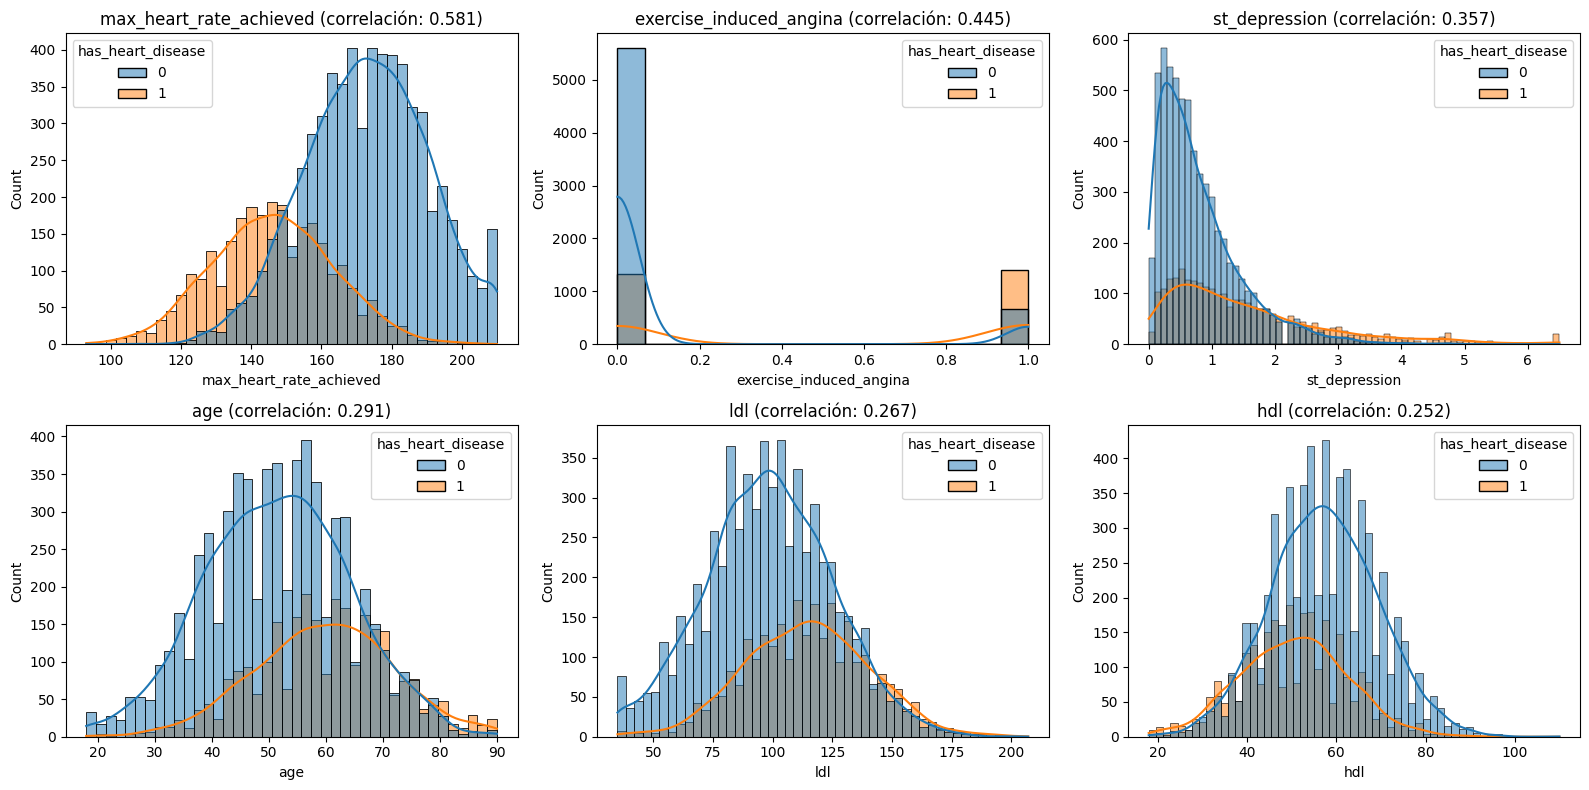


Variables categóricas encontradas: ['sex', 'chest_pain_type', 'smoker_status']


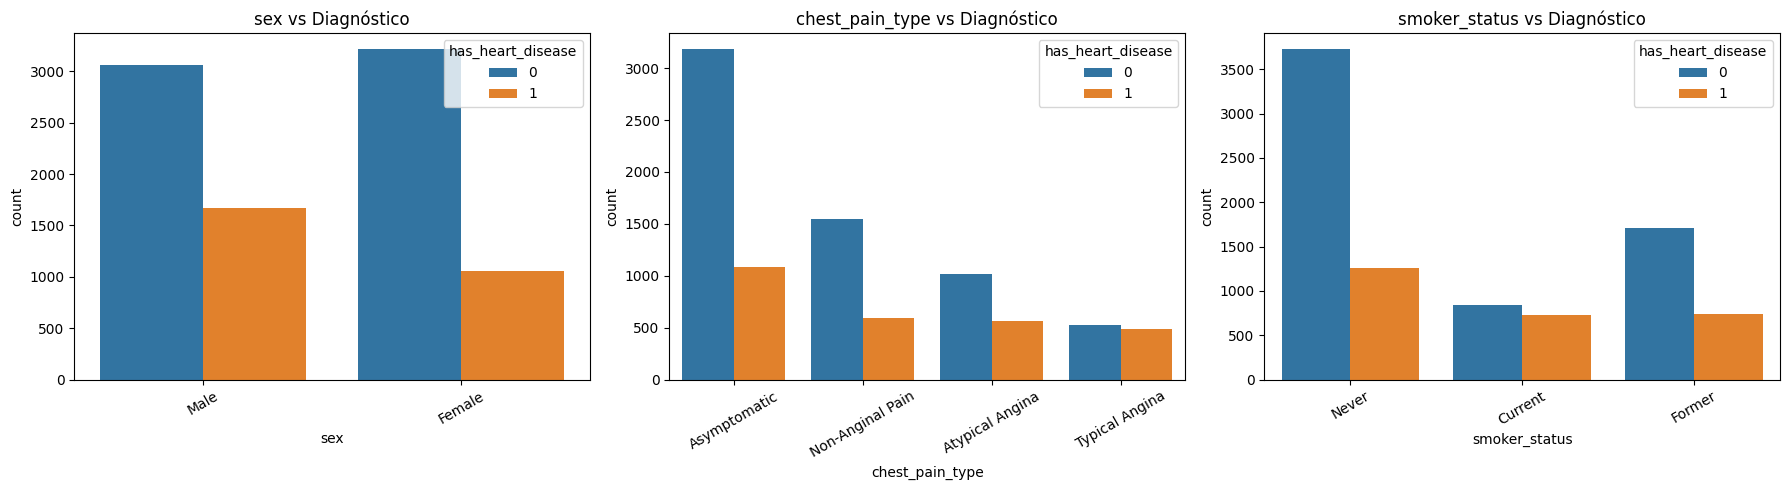

In [ ]:
# ============================================================
# 1. Variables NUMÉRICAS: correlación con la variable objetivo
# ============================================================
df_numerico = df.select_dtypes(include=['int64', 'float64', 'bool'])

correlaciones = df_numerico.corr()['has_heart_disease'].abs().sort_values(ascending=False)

print("Correlación de variables numéricas con has_heart_disease:")
print(correlaciones)

# Seleccionar las top 6 más correlacionadas (excluyendo la propia variable objetivo y el id)
top_variables = (
    correlaciones.drop(['has_heart_disease', 'patient_id'], errors='ignore')
    .head(6)
    .index.tolist()
)
print(f"\nVariables numéricas seleccionadas para graficar: {top_variables}")

# Graficar cada una comparando contra el diagnóstico
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(top_variables):
    sns.histplot(data=df, x=var, hue='has_heart_disease', kde=True, ax=axes[i])
    axes[i].set_title(f'{var} (correlación: {correlaciones[var]:.3f})')

plt.tight_layout()
plt.show()

# ============================================================
# 2. Variables CATEGÓRICAS: distribución frente al diagnóstico
# ============================================================
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables categóricas encontradas: {variables_categoricas}")

fig, axes = plt.subplots(1, len(variables_categoricas), figsize=(6*len(variables_categoricas), 5))
axes = axes if len(variables_categoricas) > 1 else [axes]

for i, var in enumerate(variables_categoricas):
    sns.countplot(data=df, x=var, hue='has_heart_disease', ax=axes[i])
    axes[i].set_title(f'{var} vs Diagnóstico')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# **Análisis de Distribución de Variables: Clasificación Binaria**  *has_heart_disease* *

## **1. Introducción**
El presente análisis evalúa la distribución de las variables independientes frente a la variable objetivo **has_heart_disease** (donde **0** indica ausencia de enfermedad cardíaca y **1** indica presencia), con el fin de identificar el poder discriminativo de cada característica para el modelo de clasificación.

---

## **2. Análisis de Variables Categóricas**
Las distribuciones de frecuencias cruzadas con el diagnóstico muestran el comportamiento de las siguientes variables:

* **sex**: Presenta casos positivos en ambos grupos, destacando que los hombres (**Male**) concentran el mayor volumen absoluto de registros analizados en el conjunto de datos.
* **chest_pain_type**: Se divide en cuatro categorías (**Asymptomatic**, **Non-Anginal Pain**, **Atypical Angina**, **Typical Angina**). La categoría **Asymptomatic** agrupa la mayor cantidad de observaciones y un volumen elevado de casos positivos (**1**), constituyendo un factor categórico determinante.
* **smoker_status**: Agrupada en **Never**, **Current** y **Former**. La categoría **Never** concentra la mayor cantidad de registros generales, manteniendo una proporción constante de casos positivos en los distintos subgrupos.

---

## **3. Análisis de Variables Numéricas y Correlación**
Las variables numéricas exhiben distintos grados de separación y correlación lineal respecto a la clase objetivo:

* **max_heart_rate_achieved** (Correlación: **0.581**):
    * Registra la correlación más alta del conjunto de datos.
    * Muestra una clara separación visual: los pacientes sanos (**0**) alcanzan frecuencias cardíacas máximas más elevadas (centro cercano a **170**), mientras que los positivos (**1**) se desplazan hacia valores menores (cercanos a **140-145**).
* **exercise_induced_angina** (Correlación: **0.445**):
    * Presenta una fuerte concentración en los extremos binarios, permitiendo diferenciar de forma evidente la presencia o ausencia de la condición en relación con la enfermedad.
* **st_depression** (Correlación: **0.357**):
    * Muestra un sesgo hacia la derecha. Los valores bajos predominan en la clase **0**, en tanto que valores más altos de depresión del segmento ST incrementan la densidad de casos positivos.
* **age** (Correlación: **0.291**):
    * Presenta una distribución normal desplazada, donde los pacientes con enfermedad cardíaca se concentran en rangos etarios superiores (pico entre **60** y **65 años**) frente al grupo sano (pico entre **50** y **55 años**).
* **ldl** (Correlación: **0.267**) y **hdl** (Correlación: **0.252**):
    * Exhiben distribuciones normales superpuestas con correlaciones moderadas, aportando información complementaria para el modelo predictivo.

---

## **4. Conclusiones y Consideraciones para el Modelado**
* **Variables clave**: **max_heart_rate_achieved**, **exercise_induced_angina** y **st_depression** destacan como los predictores numéricos más fuertes debido a sus niveles de correlación y la separación de sus distribuciones.
* **Preprocesamiento**: Dada la naturaleza de las distribuciones, se recomienda aplicar estandarización (como **StandardScaler**) si se utilizan modelos lineales o de distancia, y considerar algoritmos basados en árboles que aprovechen de forma nativa estos puntos de corte.

# **6.3 transformación de las variables categoricas a números**

In [ ]:
variables_nominales = [
    "sex",
    "chest_pain_type",
    "smoker_status"
]

variables_ordinales = [
    "exercise_induced_angina",
    "family_history",
    "wearable_owner"
]

df_encoded = df.copy()

# 1. Variables nominales (One-Hot Encoding) y forzar a entero
if variables_nominales:
    df_encoded = pd.get_dummies(df_encoded, columns=variables_nominales, drop_first=True, dtype=int)

# 2. Variables ordinales (Ordinal Encoding) y asegurar tipo numérico
if variables_ordinales:
    encoder = OrdinalEncoder()
    df_encoded[variables_ordinales] = encoder.fit_transform(df_encoded[variables_ordinales])
    df_encoded[variables_ordinales] = df_encoded[variables_ordinales].astype(int)

print("Transformación completada con éxito.")
display(df_encoded.sample(4))

Transformación completada con éxito.


,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,sex_Male,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,smoker_status_Former,smoker_status_Never
6704,6705,57,121,66,189,59,105,125,115,5.9,...,0,9072,62.9,0,1,0,1,0,0,1
7729,7730,31,102,71,189,29,99,284,122,6.0,...,0,4750,59.0,0,1,0,0,0,0,0
2010,2011,51,141,92,163,58,95,89,87,4.8,...,0,6980,86.2,0,0,0,0,0,0,1
5877,5878,44,119,74,218,39,116,268,90,5.0,...,0,5189,34.2,0,0,0,0,0,0,0


# **6.4 Se eliminan variables que no aportan información**

In [ ]:
df_encoded = df_encoded.drop(columns=['patient_id'], errors='ignore')
df_encoded.sample(4)

,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,...,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,sex_Male,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,smoker_status_Former,smoker_status_Never
5997,36,115,75,185,43,95,223,119,6.4,32.0,...,0,8723,46.5,1,1,0,0,0,0,1
8028,77,144,88,232,40,135,265,112,5.9,30.7,...,1,5869,68.0,1,1,0,1,0,0,0
4745,67,127,84,180,50,111,81,109,5.7,25.4,...,0,1251,74.9,0,0,0,0,0,0,1
4239,71,147,81,157,56,69,143,134,6.4,31.4,...,1,8407,100.0,0,1,0,0,1,0,1


# **7. Obtencion de los datos de entrenamiento y de test**

In [ ]:
y = df_encoded['has_heart_disease']
X = df_encoded.drop(columns=['has_heart_disease'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones de prueba (X_test): {X_test.shape}")

Dimensiones de entrenamiento (X_train): (7200, 28)
Dimensiones de prueba (X_test): (1800, 28)


## **7.1 Distribucion de la variable objetivo**

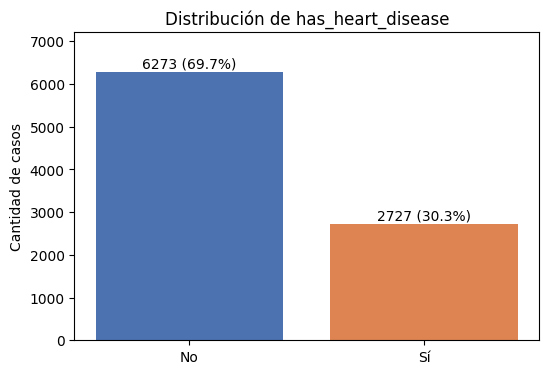

In [ ]:
conteo = y.value_counts().sort_index()
porcentaje = y.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
plt.bar(['No', 'Sí'], conteo.values, color=['#4C72B0', '#DD8452'])
plt.title('Distribución de has_heart_disease')
plt.ylabel('Cantidad de casos')
plt.ylim(0, max(conteo.values) * 1.15)

for i, (count, pct) in enumerate(zip(conteo.values, porcentaje.values)):
    plt.text(i, count + 100, f'{count} ({pct:.1f}%)', ha='center')

plt.show()

# **7.2 Escalado de las variables numéricas**

In [ ]:
# Identificar variables numéricas a escalar (excluyendo nominales y ordinales ya codificadas)
variables_numericas = [
    col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
    if col not in variables_nominales
    and col not in variables_ordinales
]

# Escalar: fit SOLO en train, transform en train y test
scaler = StandardScaler()

X_train[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_test[variables_numericas] = scaler.transform(X_test[variables_numericas])

print("Escalado completado sin leakage.")
X_train.sample(4)

Escalado completado sin leakage.


,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,...,stress_score,wearable_owner,daily_steps,diet_quality_score,sex_Male,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,smoker_status_Former,smoker_status_Never
8850,1.849168,2.106555,1.286390,-1.262298,-0.424300,-0.816190,-0.546778,2.001126,1.599277,1.485736,...,0.976213,1,-0.688466,-1.658992,0.952250,-0.46278,-0.559170,2.777896,-0.616096,-1.112079
4350,0.306829,0.294491,-0.535011,0.653578,0.950824,-0.451020,0.856356,1.124096,0.736067,-2.134709,...,0.913981,0,-0.307363,-0.595525,-1.050145,-0.46278,1.788365,-0.359985,1.623123,-1.112079
5043,1.926285,0.222008,0.284619,-1.015088,-0.586079,-0.268435,-1.267834,0.992542,0.448330,-1.155595,...,0.192094,1,0.422545,1.137788,-1.050145,-0.46278,-0.559170,-0.359985,-0.616096,0.899217
6906,-1.312627,0.294491,0.922110,-0.458866,0.708155,-1.035292,-0.137531,-0.323003,0.592198,0.165071,...,0.297888,0,2.059072,2.429140,-1.050145,-0.46278,-0.559170,-0.359985,-0.616096,-1.112079


## **8. Modelo Vecinos Más Cercanos Knn**

In [ ]:

# 1. Configurar validación cruzada estratificada para respetar la proporción de clases
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Configurar GridSearchCV optimizando por F1-macro (ideal para clases desbalanceadas)
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)




## **8.1 Entrenamiento del Modelo Vecinos Más Cercanos Knn**

Buscando la mejor configuración para KNN

Mejores hiperparámetros encontrados: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}

--- Resultados del modelo KNN Optimizado ---
Exactitud (Accuracy): 0.8289

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1255
           1       0.88      0.51      0.64       545

    accuracy                           0.83      1800
   macro avg       0.85      0.74      0.76      1800
weighted avg       0.84      0.83      0.81      1800



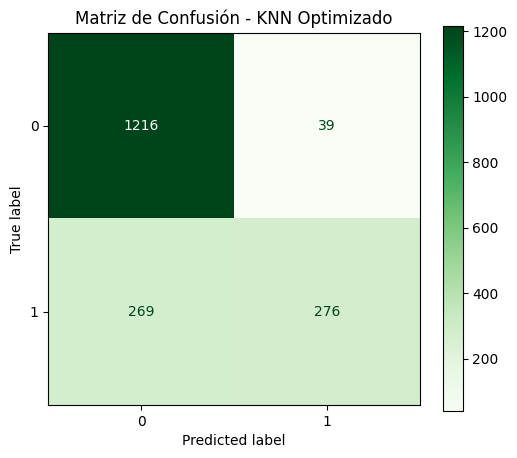

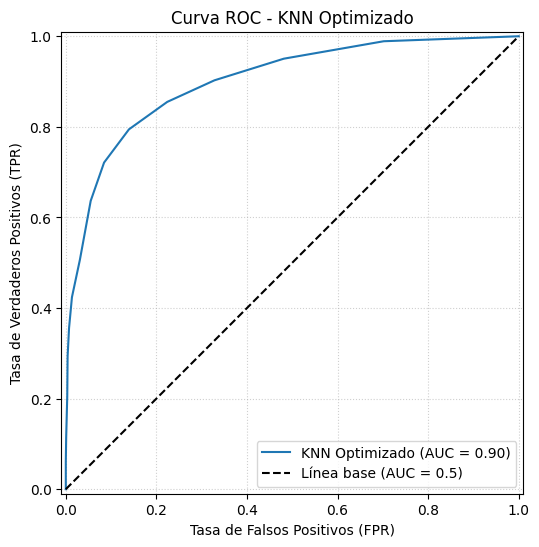

In [ ]:
print("Buscando la mejor configuración para KNN")
grid_search.fit(X_train, y_train)

mejor_knn = grid_search.best_estimator_
print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}\n")

y_pred_knn = mejor_knn.predict(X_test)

print("--- Resultados del modelo KNN Optimizado ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Reporte de clasificación detallado:")
print(classification_report(y_test, y_pred_knn))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(mejor_knn, X_test, y_test, cmap='Greens', ax=ax, values_format='d')
plt.title("Matriz de Confusión - KNN Optimizado")
# Generar y graficar la curva ROC para el modelo KNN optimizado
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(mejor_knn, X_test, y_test, ax=ax, name="KNN Optimizado")

plt.plot([0, 1], [0, 1], 'k--', label="Línea base (AUC = 0.5)")
plt.title("Curva ROC - KNN Optimizado")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")
plt.show()

## **9. Árboles de Desición**

In [ ]:

# 1. Configurar validación cruzada estratificada para manejar el desbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir la rejilla de hiperparámetros para controlar el sobreajuste y el desbalance (class_weight)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

# 3. Configurar GridSearchCV optimizando por F1-macro
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)




# **9.1 Entrenamiento del modelo Árbol de desición**

In [ ]:
# 4. Entrenar el modelo
print("Buscando la mejor configuración para el Árbol de Decisión...")
grid_search_dt.fit(X_train, y_train)

# Mejor modelo encontrado
mejor_dt = grid_search_dt.best_estimator_
print(f"\nMejores hiperparámetros encontrados: {grid_search_dt.best_params_}\n")



Buscando la mejor configuración para el Árbol de Decisión...

Mejores hiperparámetros encontrados: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}



--- Resultados del Árbol de Decisión Optimizado ---
Exactitud (Accuracy): 0.8544

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1255
           1       0.80      0.69      0.74       545

    accuracy                           0.85      1800
   macro avg       0.84      0.81      0.82      1800
weighted avg       0.85      0.85      0.85      1800



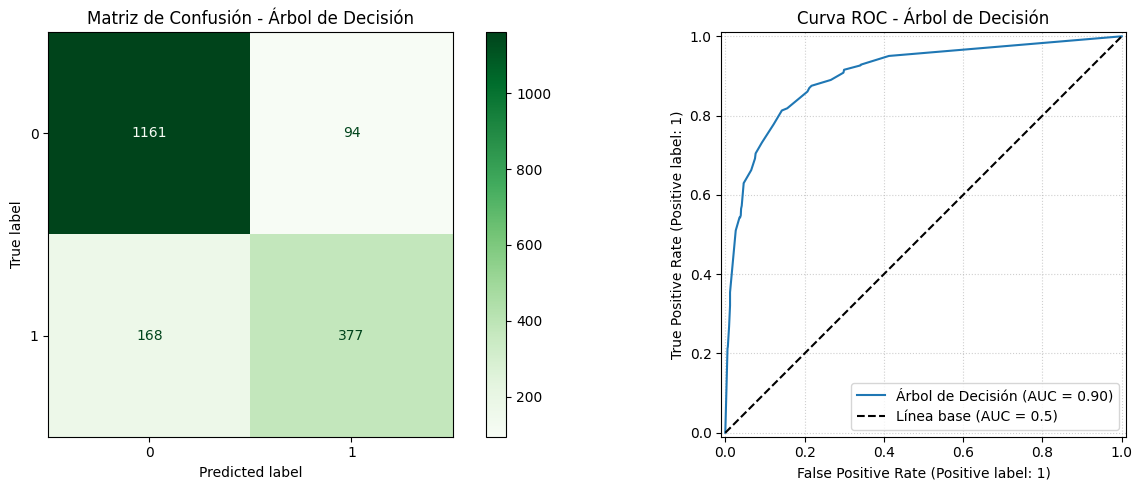

In [ ]:
# 5. Evaluar en el conjunto de prueba
y_pred_dt = mejor_dt.predict(X_test)

print("--- Resultados del Árbol de Decisión Optimizado ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Reporte de clasificación detallado:")
print(classification_report(y_test, y_pred_dt))

# 6. Gráficos de evaluación (Matriz de Confusión y Curva ROC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(mejor_dt, X_test, y_test, cmap='Greens', ax=axes[0], values_format='d')
axes[0].set_title("Matriz de Confusión - Árbol de Decisión")

# Curva ROC
RocCurveDisplay.from_estimator(mejor_dt, X_test, y_test, ax=axes[1], name="Árbol de Decisión")
axes[1].plot([0, 1], [0, 1], 'k--', label="Línea base (AUC = 0.5)")
axes[1].set_title("Curva ROC - Árbol de Decisión")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# **10. Regresión Logística**

Buscando la mejor configuración para Regresión Logística...

Mejores hiperparámetros encontrados: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

--- Resultados de Regresión Logística Optimizado ---
Exactitud (Accuracy): 0.8967

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1255
           1       0.86      0.79      0.82       545

    accuracy                           0.90      1800
   macro avg       0.89      0.87      0.87      1800
weighted avg       0.90      0.90      0.90      1800



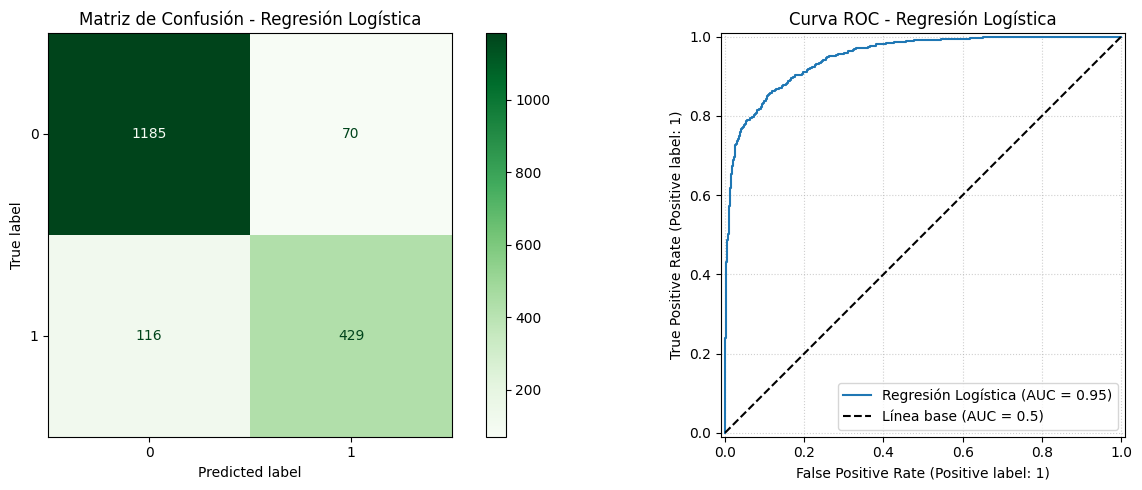

In [ ]:
# 1. Configurar validación cruzada estratificada para manejar el desbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir la rejilla de hiperparámetros (incluyendo class_weight para el desbalance y solver compatible con l1/l2)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}

# 3. Configurar GridSearchCV optimizando por F1-macro
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

# 4. Entrenar el modelo
print("Buscando la mejor configuración para Regresión Logística...")
grid_search_lr.fit(X_train, y_train)

# Mejor modelo encontrado
mejor_lr = grid_search_lr.best_estimator_
print(f"\nMejores hiperparámetros encontrados: {grid_search_lr.best_params_}\n")

# 5. Evaluar en el conjunto de prueba
y_pred_lr = mejor_lr.predict(X_test)

print("--- Resultados de Regresión Logística Optimizado ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Reporte de clasificación detallado:")
print(classification_report(y_test, y_pred_lr))

# 6. Gráficos de evaluación (Matriz de Confusión y Curva ROC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(mejor_lr, X_test, y_test, cmap='Greens', ax=axes[0], values_format='d')
axes[0].set_title("Matriz de Confusión - Regresión Logística")

# Curva ROC
RocCurveDisplay.from_estimator(mejor_lr, X_test, y_test, ax=axes[1], name="Regresión Logística")
axes[1].plot([0, 1], [0, 1], 'k--', label="Línea base (AUC = 0.5)")
axes[1].set_title("Curva ROC - Regresión Logística")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# **11. Comparación de Modelos**

--- TABLA COMPARATIVA DE RENDIMIENTO ---


,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC-AUC
Modelo,,,,,
KNN Optimizado,0.828889,0.847523,0.737673,0.764726,0.901232
Árbol de Decisión,0.854444,0.837007,0.808421,0.820366,0.903649
Regresión Logística,0.896667,0.885279,0.865690,0.874535,0.949716


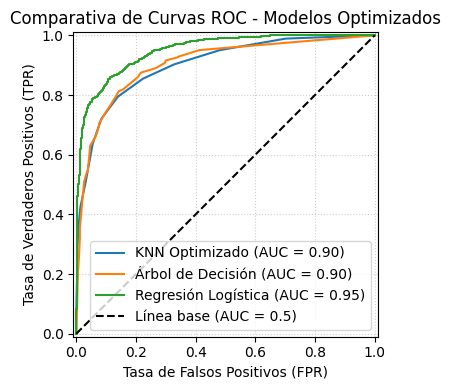

In [ ]:
# 1. Recopilar métricas de los tres modelos optimizados
modelos_dict = {
    "KNN Optimizado": mejor_knn,
    "Árbol de Decisión": mejor_dt,
    "Regresión Logística": mejor_lr
}

resultados = []

for nombre, modelo in modelos_dict.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_test, y_pred, average='macro'),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    })

# 2. Crear DataFrame comparativo
df_comparacion = pd.DataFrame(resultados)
print("--- TABLA COMPARATIVA DE RENDIMIENTO ---")
display(df_comparacion.set_index("Modelo"))

# 3. Graficar todas las Curvas ROC juntas
fig, ax = plt.subplots(figsize=(5, 4))

for nombre, modelo in modelos_dict.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=nombre)

plt.plot([0, 1], [0, 1], 'k--', label="Línea base (AUC = 0.5)")
plt.title("Comparativa de Curvas ROC - Modelos Optimizados")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()